In [3]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np
from tqdm import tqdm
import json 

In [4]:
filename = "data/llama_truthfulqa_results.json"
with open(filename, "r", encoding="utf-8") as f:
    results = json.load(f)
print(f"Loaded {len(results)} questions from file.")

Loaded 100 questions from file.


In [ ]:
# 1. Load the NLI Model (DeBERTa-v3 is highly recommended for logic)
model_name = "cross-encoder/nli-deberta-v3-small" 
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

def calculate_nli_coherence(samples):
    """
    Calculates coherence based on logical contradictions between samples.
    High Contradiction = Low Coherence.
    """
    contradiction_scores = []
    
    # We compare the first sample (representative) against the others
    # Logic: If samples[0] contradicts samples[1...4], the model is hallucinating.
    premise = samples[0]
    hypotheses = samples[1:]
    
    for hypo in hypotheses:
        # Encode the pair (Premise, Hypothesis)
        inputs = tokenizer(premise, hypo, truncation=True, return_tensors="pt")
        
        with torch.no_grad():
            logits = model(**inputs).logits
            # The model outputs 3 classes: [Entailment, Neustral, Contradiction]
            probs = torch.softmax(logits, dim=1).numpy()[0]
            
            # Index 2 is usually 'Contradiction' for this specific model
            contradiction_prob = probs[2] 
            contradiction_scores.append(contradiction_prob)
    
    # Coherence = 1 - Average Contradiction, because Entailment is too restrictive
    avg_contradiction = np.mean(contradiction_scores)
    return 1 - avg_contradiction

# 2. Apply NLI to your results
nli_coherence_scores = []

print("Computing NLI Coherence scores...")
for item in tqdm(results):
    nli_score = calculate_nli_coherence(item['samples'])
    nli_coherence_scores.append(nli_score)
    
    # Enrich the JSON object
    item['nli_coherence_score'] = round(float(nli_score), 4)

print("NLI processing complete.")

tokenizer_config.json: 0.00B [00:00, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/568M [00:00<?, ?B/s]

Computing NLI Coherence scores...


100%|██████████| 100/100 [00:13<00:00,  7.48it/s]

NLI processing complete.


Establishing Ground Truth labels via NLI Entailment check...


100%|██████████| 100/100 [00:02<00:00, 37.37it/s]


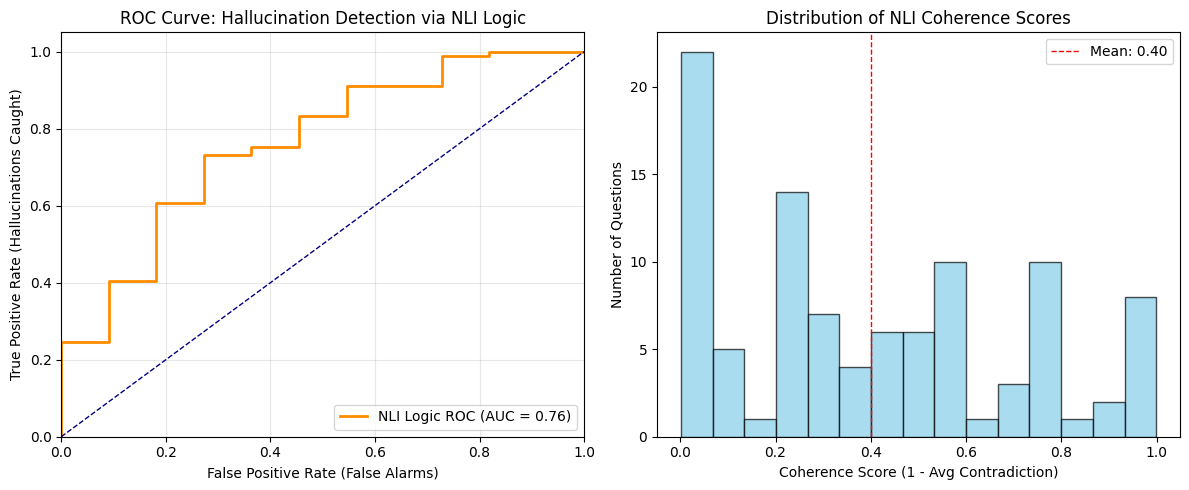

--- NLI Evaluation Summary ---
Total Hallucinations (Logic-based): 89
Total True Answers (Logic-based): 11
NLI Detection AUC: 0.7620


In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from tqdm import tqdm

# --- 1. GENERATE GROUND TRUTH LABELS USING NLI ---
# We check if the first answer logically contradicts the ground truth
print("Establishing Ground Truth labels via NLI Entailment check...")
nli_labels = [] # 1 for Hallucination, 0 for True

for item in tqdm(results):
    premise = item['ground_truth']
    hypothesis = item['samples'][0]
    
    inputs = tokenizer(premise, hypothesis, truncation=True, return_tensors="pt")
    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=1).numpy()[0]
        # Index 0: Entailment, 1: Neutral, 2: Contradiction
        # If Contradiction > Entailment, we classify it as a Hallucination (Label 1)
        if probs[2] > probs[0]:
            nli_labels.append(1)
        else:
            nli_labels.append(0)

# --- 2. CALCULATE ROC METRICS ---
# Our predictor is the "Contradiction probability" between samples
# High contradiction = High chance of being a Hallucination
nli_hallucination_signal = [1 - s for s in nli_coherence_scores]

fpr, tpr, thresholds = roc_curve(nli_labels, nli_hallucination_signal)
roc_auc = auc(fpr, tpr)

# --- 3. PLOTTING THE RESULTS ---
plt.figure(figsize=(12, 5))

# Subplot 1: ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'NLI Logic ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Hallucinations Caught)')
plt.title('ROC Curve: Hallucination Detection via NLI Logic')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Subplot 2: Score Distribution
plt.subplot(1, 2, 2)
plt.hist(nli_coherence_scores, bins=15, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(np.mean(nli_coherence_scores), color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(nli_coherence_scores):.2f}')
plt.title('Distribution of NLI Coherence Scores')
plt.xlabel('Coherence Score (1 - Avg Contradiction)')
plt.ylabel('Number of Questions')
plt.legend()

plt.tight_layout()
plt.savefig("nli_only_results.png", dpi=300)
plt.show()

print(f"--- NLI Evaluation Summary ---")
print(f"Total Hallucinations (Logic-based): {sum(nli_labels)}")
print(f"Total True Answers (Logic-based): {len(nli_labels) - sum(nli_labels)}")
print(f"NLI Detection AUC: {roc_auc:.4f}")